# Convolution Japanese seismic acceleration

## Dataset
Source: IRIS/SAGE FDSN Web Service (via ObsPy)

Network / Station: IU.MAJO — Matsushiro, Nagano, Japan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from numpy.fft import rfft, rfftfreq

plt.rcParams["figure.figsize"] = (10,3)
plt.rcParams["axes.grid"] = True

client = Client("IRIS")   # Data provider
STATION = ("IU", "MAJO", "*", "BHZ")  # network, station, location, channel

## Data

In [3]:
def fetch_majo_window_around_recent_event(min_mag=5.5, search_days=200, pre_s=15*60, post_s=15*60):
    try:
        t_end = UTCDateTime()
        t_start = t_end - search_days*24*3600
        cat = client.get_events(minmagnitude=min_mag,
                                starttime=t_start, endtime=t_end,
                                minlatitude=20, maxlatitude=48,
                                minlongitude=122, maxlongitude=154)
        ev = sorted(cat, key=lambda e: e.origins[0].time)[-1]
        ot = ev.origins[0].time
        print(f"Event: {ev.resource_id}  OT={ot}  Mw≈{ev.magnitudes[0].mag:.1f}")
        st = client.get_waveforms(*STATION, starttime=ot-pre_s, endtime=ot+post_s, attach_response=True)
    except Exception as e:
        print("Event search failed; falling back to last 30 minutes around now.\n", e)
        t_end = UTCDateTime()
        st = client.get_waveforms(*STATION, starttime=t_end-30*60, endtime=t_end, attach_response=True)
    return st

st = fetch_majo_window_around_recent_event()

Event: smi:service.iris.edu/fdsnws/event/1/query?eventid=12026363  OT=2025-10-04T15:21:09.034000Z  Mw≈5.9


IU.MAJO.00.BHZ | 2025-10-04T15:06:09.044538Z - 2025-10-04T15:36:09.019538Z | 40.0 Hz, 72000 samples
Sampling rate: 40.00 Hz | Samples: 72000 | Duration: 30.0 min


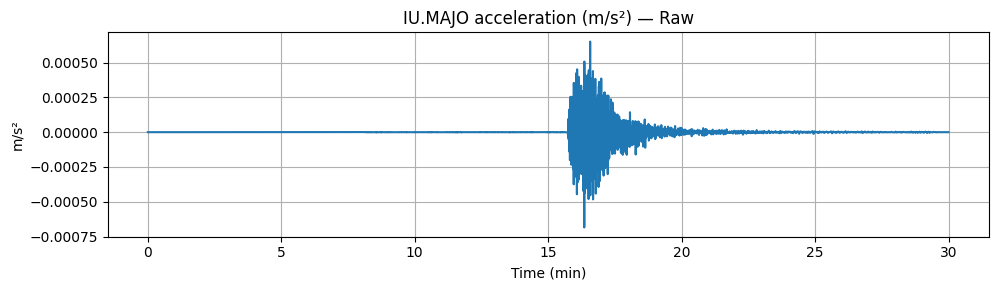

In [4]:
st.remove_response(output="ACC")   # -> acceleration
st.detrend("linear").detrend("demean").taper(0.02)
st = st.merge(fill_value="interpolate")
tr = st[0]

fs = 1.0 / tr.stats.delta
dt = tr.stats.delta
t  = np.arange(tr.stats.npts) / fs
acc = tr.data.astype(float)

print(tr)
print(f"Sampling rate: {fs:.2f} Hz | Samples: {tr.stats.npts} | Duration: {tr.stats.npts/fs/60:.1f} min")

plt.plot(t/60, acc)
plt.title("IU.MAJO acceleration (m/s²) — Raw")
plt.xlabel("Time (min)")
plt.ylabel("m/s²")
plt.tight_layout()
plt.show()

## Helpers

In [5]:
from numpy.lib.stride_tricks import sliding_window_view

def conv1d_own(x, h, padding="reflect", causal=False):
    x = np.asarray(x, float); h = np.asarray(h, float)
    K = len(h)
    if causal:
        h_use = h[::-1]
        pad_left, pad_right = K-1, 0
    else:
        h_use = h[::-1]
        pad_left = (K-1)//2
        pad_right = K-1 - pad_left

    if padding == "reflect":
        xpad = np.pad(x, (pad_left, pad_right), mode="reflect")
    elif padding == "edge":
        xpad = np.pad(x, (pad_left, pad_right), mode="edge")
    elif padding == "constant":
        xpad = np.pad(x, (pad_left, pad_right), mode="constant")
    else:
        raise ValueError("Unknown padding")

    W = sliding_window_view(xpad, K)
    y = W @ h_use
    return y[:len(x)]

In [6]:
def lowpass_fir(cut_hz, fs, L, window="hamming"):
    if L % 2 == 0: L += 1
    n  = np.arange(L) - (L-1)/2
    fc = cut_hz / fs
    h_ideal = 2*fc * np.sinc(2*fc * n)      # np.sinc uses π-normalization
    if window == "hamming":
        w = 0.54 - 0.46*np.cos(2*np.pi*np.arange(L)/(L-1))
    elif window == "blackman":
        w = 0.42 - 0.5*np.cos(2*np.pi*np.arange(L)/(L-1)) + 0.08*np.cos(4*np.pi*np.arange(L)/(L-1))
    else:
        raise ValueError("window must be 'hamming' or 'blackman'")
    h = h_ideal * w
    h /= np.sum(h)                          # unity DC gain
    return h

def gaussian_kernel(L, sigma):
    if L % 2 == 0: L += 1
    n = np.arange(L) - (L-1)/2
    g = np.exp(-0.5*(n/sigma)**2)
    g /= g.sum()
    return g

def dog_kernel(L, sigma1, sigma2):
    g1 = gaussian_kernel(L, sigma1)
    g2 = gaussian_kernel(L, sigma2)
    k = g1 - g2
    return k - k.mean()

In [7]:
g0 = 9.81

def arias_intensity(a, dt, g=g0):
    # IA = (π/(2g)) * ∑ a(t)^2 dt
    return (np.pi/(2*g))*np.sum(a*a)*dt

def pga(a):
    return np.max(np.abs(a))

def band_power(a, fs, f_lo, f_hi):
    A = rfft(a)
    f = rfftfreq(a.size, 1/fs)
    P = (np.abs(A)**2)/a.size
    mask_in  = (f >= f_lo) & (f <= f_hi)
    mask_out = ~mask_in
    return P[mask_in].sum(), P[mask_out].sum()

def snr_band(a, fs, f_lo=0.5, f_hi=10.0):
    pin, pout = band_power(a, fs, f_lo, f_hi)
    return 10*np.log10((pin+1e-12)/(pout+1e-12))

def xcorr_lag_ms(x, y, fs):
    x0 = x - np.mean(x); y0 = y - np.mean(y)
    c = np.correlate(y0, x0, mode='full')
    lag = np.argmax(c) - (len(x0)-1)
    return (lag*1000.0/fs), lag

## Day 10

### Problem Statement & Use Case (WHAT & WHY)

#### WHAT:
Filter a real Japanese seismic acceleration time series to (a) reduce high-frequency noise and (b) enhance onsets, without distorting event timing.

##### PGA (Peak Ground Acceleration):
Critical for engineering demand; filters must not overdampen peaks.

##### Arias Intensity (IA):
Measures cumulative shaking energy; smoothing should not misrepresent energy.

##### Band-SNR (0.5–10 Hz):
Operational band for many strong-motion use cases; we seek to improve in-band clarity vs out-of-band noise.

##### Phase/Group Delay:
Causal filters shift arrivals; acausal (zero-phase-like) filters preserve timing. We quantify the lag to make that trade-off explicit.

### Filters

In [8]:
cut = min(10.0, 0.45*fs)          # keep well below Nyquist
L_lp = 101 if fs >= 50 else 61    # odd lengths
h_hamm  = lowpass_fir(cut, fs, L_lp, "hamming")
h_black = lowpass_fir(cut, fs, L_lp, "blackman")
h_dog   = dog_kernel(L=61 if fs>=50 else 41, sigma1=2.0, sigma2=6.0)

In [9]:
acc_lp_hamm         = conv1d_own(acc, h_hamm,  padding="reflect", causal=False)
acc_lp_black        = conv1d_own(acc, h_black, padding="reflect", causal=False)
acc_lp_hamm_causal  = conv1d_own(acc, h_hamm,  padding="edge",    causal=True)
acc_dog             = conv1d_own(acc, h_dog,   padding="reflect", causal=False)

# Parity with NumPy for constant padding
y_own_const = conv1d_own(acc, h_hamm, padding="constant", causal=False)
y_np        = np.convolve(acc, h_hamm, mode="same")
print("NumPy parity (zero padding): "
      f"L2={np.linalg.norm(y_own_const - y_np):.3e}, "
      f"max|Δ|={np.max(np.abs(y_own_const - y_np)):.3e}")

NumPy parity (zero padding): L2=1.841e-18, max|Δ|=2.168e-19


### KPI's

In [10]:
dt = 1.0/fs
variants = {
    "raw": acc,
    "LP Hamming (acausal)": acc_lp_hamm,
    "LP Blackman (acausal)": acc_lp_black,
    "LP Hamming (causal)": acc_lp_hamm_causal,
    "DoG (edge) (acausal)": acc_dog,
}

In [11]:
IA_raw  = arias_intensity(acc, dt)
PGA_raw = pga(acc)
SNR_raw = snr_band(acc, fs)

rows = []
for name, sig in variants.items():
    IA   = arias_intensity(sig, dt)
    PGA  = pga(sig)
    SNR  = snr_band(sig, fs)
    lag_ms, lag_samp = xcorr_lag_ms(acc, sig, fs)
    rows.append({
        "Variant": name,
        "PGA (m/s^2)": PGA,
        "PGA change vs raw (%)": 100*(PGA-PGA_raw)/PGA_raw,
        "Arias Intensity": IA,
        "IA change vs raw (%)": 100*(IA-IA_raw)/IA_raw,
        f"SNR 0.5–{int(min(10,0.45*fs))} Hz (dB)": SNR,
        "SNR improvement (dB)": SNR - SNR_raw,
        "Lag vs raw (ms)": lag_ms,
        "Lag samples": lag_samp
    })

kpi_df = pd.DataFrame(rows).round(4)
kpi_df

,Variant,PGA (m/s^2),PGA change vs raw (%),Arias Intensity,IA change vs raw (%),SNR 0.5–10 Hz (dB),SNR improvement (dB),Lag vs raw (ms),Lag samples
0,raw,0.0007,0.0000,0.0,0.0000,7.6863,0.0000,0.0,0
1,LP Hamming (acausal),0.0007,0.0015,0.0,-0.2176,7.7002,0.0139,0.0,0
2,LP Blackman (acausal),0.0007,0.0416,0.0,-0.0679,7.6999,0.0136,0.0,0
3,LP Hamming (causal),0.0007,0.0015,0.0,-0.2176,7.7002,0.0139,750.0,30
4,DoG (edge) (acausal),0.0004,-45.3282,0.0,-79.5131,27.9871,20.3008,0.0,0


### Visual Comparisons

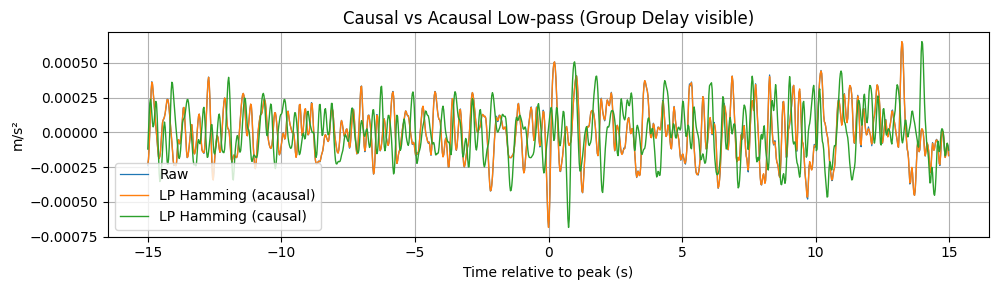

In [12]:
imax = np.argmax(np.abs(acc))
w = int(30*fs)  # 30 s window (shrink if needed)
L = max(0, imax - w//2); R = min(len(acc), imax + w//2)

plt.plot(t[L:R]-t[imax], acc[L:R], label="Raw", lw=0.9)
plt.plot(t[L:R]-t[imax], acc_lp_hamm[L:R], label="LP Hamming (acausal)", lw=1.0)
plt.plot(t[L:R]-t[imax], acc_lp_hamm_causal[L:R], label="LP Hamming (causal)", lw=1.0)
plt.title("Causal vs Acausal Low-pass (Group Delay visible)")
plt.xlabel("Time relative to peak (s)")
plt.ylabel("m/s²")
plt.legend()
plt.tight_layout()
plt.show()

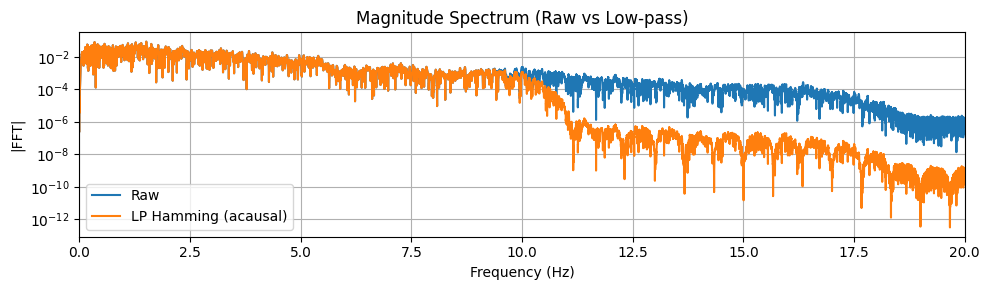

In [13]:
def mag_spectrum(a, fs):
    A = rfft(a); f = rfftfreq(a.size, 1/fs); mag = np.abs(A)
    return f, mag

fr, mag_raw = mag_spectrum(acc, fs)
_,  mag_lp  = mag_spectrum(acc_lp_hamm, fs)

plt.semilogy(fr, mag_raw, label="Raw")
plt.semilogy(fr, mag_lp,  label="LP Hamming (acausal)")
plt.xlim(0, min(40, 0.5*fs))
plt.title("Magnitude Spectrum (Raw vs Low-pass)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|FFT|")
plt.legend()
plt.tight_layout()
plt.show()

### FIR Length Sweep

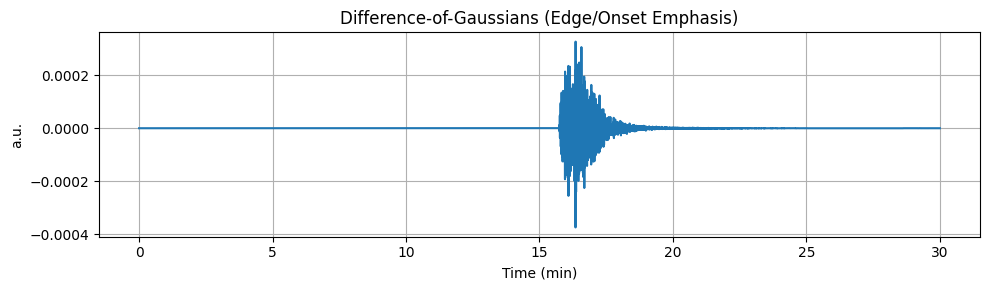

In [14]:
plt.plot(t/60, acc_dog)
plt.title("Difference-of-Gaussians (Edge/Onset Emphasis)")
plt.xlabel("Time (min)")
plt.ylabel("a.u.")
plt.tight_layout()
plt.show()

In [15]:
Ls = [31, 61, 101] if fs < 50 else [31, 61, 101, 151]
srows = []
for Lsamp in Ls:
    h = lowpass_fir(cut, fs, Lsamp, "hamming")
    y_ac = conv1d_own(acc, h, causal=False, padding="reflect")
    y_c  = conv1d_own(acc, h, causal=True,  padding="edge")
    for mode, sig in [("acausal", y_ac), ("causal", y_c)]:
        srows.append({
            "L": Lsamp, "mode": mode,
            "IA": arias_intensity(sig, dt),
            "PGA": pga(sig),
            "SNR": snr_band(sig, fs),
            "Lag_ms": xcorr_lag_ms(acc, sig, fs)[0]
        })
sweep_df = pd.DataFrame(srows).round(4)
sweep_df

,L,mode,IA,PGA,SNR,Lag_ms
0,31,acausal,0.0,0.0007,7.7136,0.0
1,31,causal,0.0,0.0007,7.7136,375.0
2,61,acausal,0.0,0.0007,7.7002,0.0
3,61,causal,0.0,0.0007,7.7002,750.0
4,101,acausal,0.0,0.0007,7.7033,0.0
5,101,causal,0.0,0.0007,7.7033,1250.0


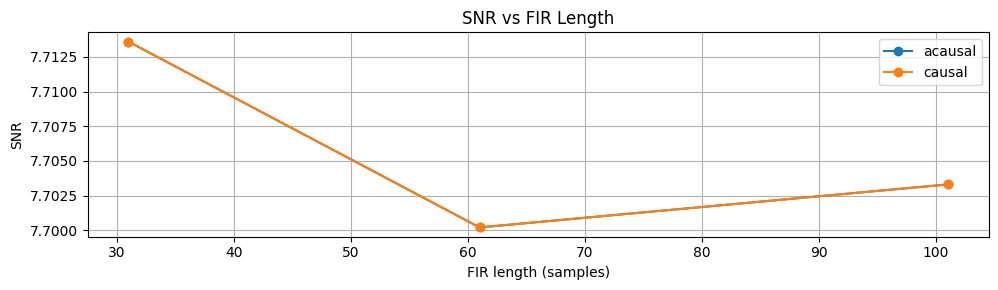

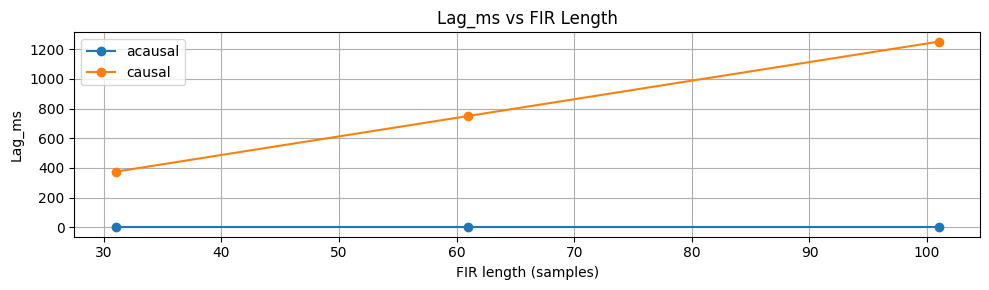

In [16]:
for metric in ["SNR", "Lag_ms"]:
    plt.plot(sweep_df[sweep_df["mode"]=="acausal"]["L"],
             sweep_df[sweep_df["mode"]=="acausal"][metric],
             marker="o", label="acausal")
    plt.plot(sweep_df[sweep_df["mode"]=="causal"]["L"],
             sweep_df[sweep_df["mode"]=="causal"][metric],
             marker="o", label="causal")
    plt.title(f"{metric} vs FIR Length")
    plt.xlabel("FIR length (samples)"); plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Takeaways
#### Acausal low-pass (Hamming/Blackman):
- Keeps amplitude/energy (PGA & IA change ≈ 0–0.2%)
- slight SNR gain (~+0.01 dB) in 0.5–10 Hz
- no lag → best for post-processing

#### Causal low-pass (Hamming):
- Similar smoothing, but adds delay ≈ (L−1)/2 samples (e.g., ~750 ms at L=61)
- Use for real-time only
- compensate for lag

#### DoG (edge enhancer):
Highlights P/S onsets with big apparent SNR boost (~+20 dB) but suppresses amplitude/energy (PGA ↓ ~45%, IA ↓ ~80%). Not suitable when amplitudes must be preserved.

#### Parameter sweep (L = 31, 61, 101):
- Acausal timing unchanged
- causal lag grows linearly with L (≈ 375 → 750 → 1250 ms)
- Pick the smallest L that meets noise goals for real-time

#### Recommendation:
- Use acausal low-pass (L≈61, cut≈10 Hz) for clean, timing-faithful results
- reserve causal for live pipelines
- use DoG only to visualize onsets

## Day 11

In [17]:
L_lp, fc_lp = 401, 12.0                 # low-pass FIR (Hamming)
h_lp   = lowpass_fir(fc_lp, fs, L_lp, window="hamming")

L_g, sig_g = 401, 12.0                  # Gaussian smoother (sigma in samples)
h_g    = gaussian_kernel(L_g, sig_g)

L_dog, sig1, sig2 = 401, 6.0, 24.0      # Difference-of-Gaussians (onset/swing enhancer)
h_dog  = dog_kernel(L_dog, sig1, sig2)

In [18]:
acc_lp  = conv1d_own(acc, h_lp,  padding="reflect", causal=False)
acc_g   = conv1d_own(acc, h_g,   padding="reflect", causal=False)
acc_dog = conv1d_own(acc, h_dog, padding="reflect", causal=False)

In [19]:
kpi11 = pd.Series({
    "PGA_raw (m/s²)": pga(acc),
    "PGA_lp": pga(acc_lp),
    "PGA_gauss": pga(acc_g),
    "Arias_raw": arias_intensity(acc, dt),
    "Arias_lp": arias_intensity(acc_lp, dt),
    "SNR_raw_0.5–10Hz (dB)": snr_band(acc, fs, 0.5, 10.0),
    "SNR_lp":  snr_band(acc_lp, fs, 0.5, 10.0),
    "SNR_gauss": snr_band(acc_g, fs, 0.5, 10.0),
})
kpi11

PGA_raw (m/s²)           6.839121e-04
PGA_lp                   6.827641e-04
PGA_gauss                1.522409e-04
Arias_raw                4.292325e-07
Arias_lp                 4.292847e-07
SNR_raw_0.5–10Hz (dB)    7.686298e+00
SNR_lp                   7.688324e+00
SNR_gauss               -5.737176e+00
dtype: float64

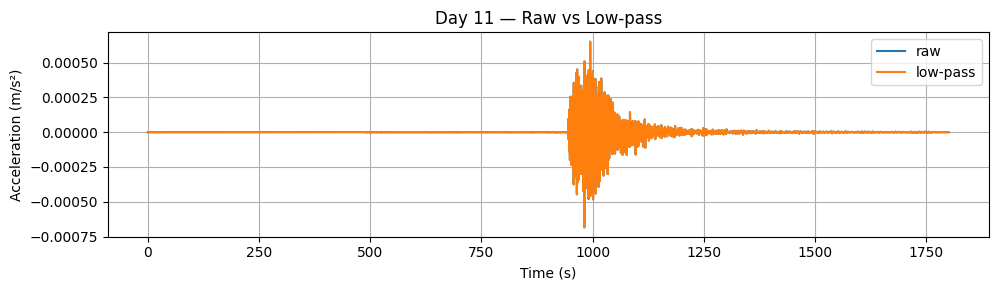

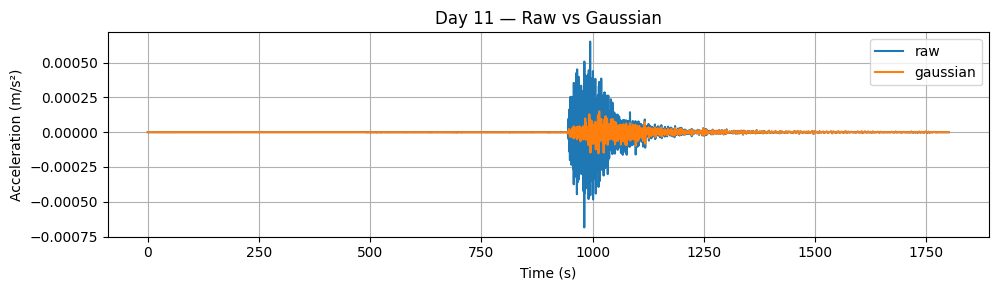

In [20]:
plt.figure(); plt.plot(t, acc, label="raw"); plt.plot(t, acc_lp, label="low-pass")
plt.xlabel("Time (s)"); plt.ylabel("Acceleration (m/s²)"); plt.title("Day 11 — Raw vs Low-pass"); plt.legend(); plt.tight_layout()

plt.figure(); plt.plot(t, acc, label="raw"); plt.plot(t, acc_g, label="gaussian")
plt.xlabel("Time (s)"); plt.ylabel("Acceleration (m/s²)"); plt.title("Day 11 — Raw vs Gaussian"); plt.legend(); plt.tight_layout()